# Proyecto NLP – Análisis de Sentimiento en Tweets  
## Binario (0/4) + Neutral por descarte (3 clases)  
### EDA mejorado + lematización acelerada + nombres de variables “de clase”

**Idea central:**  
Entrenamos modelos **binarios** en el dataset grande (solo 0/4).  
Luego, al predecir en el dataset chico (0/2/4), asignamos neutral por descarte con umbrales.

**Convención de variables (como en clase):**
- Split interno en train grande: `X_train, X_test, y_train, y_test`
- Test externo: `X_ext, y_ext`

Incluye:
- EDA con tus elecciones (1,2,3,4,8)
- Lematización por chunks con cache parquet
- LR y NB separados con métricas Train/Test interno estilo clase
- Evaluación externa 3 clases por descarte + referencia binaria
- TextBlob baseline
- Similitud coseno


In [1]:
# ===== 0. Imports y configuración =====
import os
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt

# WordCloud
try:
    from wordcloud import WordCloud
except ImportError:
    print("Instalá wordcloud: pip install wordcloud")

# TextBlob
try:
    from textblob import TextBlob
    TEXTBLOB_AVAILABLE = True
except ImportError:
    TEXTBLOB_AVAILABLE = False
    print("Instalá textblob: pip install textblob")


Instalá wordcloud: pip install wordcloud


## 0.1 Instalación (una sola vez)

In [2]:
!pip -q install spacy==3.7.2 wordcloud
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 16.7 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Carga de datos

In [3]:
train_path = "training.1600000.processed.noemoticon.csv"
test_path  = "testdata.manual.2009.06.14.csv"
cols = ["polarity","id","date","query","user","text"]

train_df = pd.read_csv(train_path, encoding="latin-1", header=None, names=cols)
test_df  = pd.read_csv(test_path,  encoding="latin-1", header=None, names=cols)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (1600000, 6)
Test shape: (498, 6)


,polarity,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


## 2. Limpieza + lematización acelerada con cache

In [5]:
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#(\w+)")

def clean_tweet(text: str) -> str:
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = hashtag_re.sub(r"\1", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].apply(clean_tweet)
test_df["text_clean"]  = test_df["text"].apply(clean_tweet)

import spacy
from spacy.lang.en.stop_words import STOP_WORDS
nlp = spacy.load("en_core_web_sm", disable=["ner","parser"])
nlp.max_length = 2_000_000

def lemmatize_texts(texts, batch_size=5000, n_process=1):
    out=[]
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        toks=[t.lemma_.lower() for t in doc
              if t.is_alpha and t.lemma_!="-PRON-" and t.text.lower() not in STOP_WORDS]
        out.append(" ".join(toks))
    return out

def lemmatize_and_cache(df, text_col, out_path, chunk_size=200_000, batch_size=5000, n_process=1):
    if os.path.exists(out_path):
        print("✅ Cargando cache:", out_path)
        return pd.read_parquet(out_path)["text_lemma"].tolist()
    print("Lematizando por chunks...")
    texts=df[text_col].tolist()
    lemmas=[]
    for i in range(0,len(texts),chunk_size):
        chunk=texts[i:i+chunk_size]
        lem_chunk=lemmatize_texts(chunk, batch_size=batch_size, n_process=n_process)
        lemmas.extend(lem_chunk)
        print(f"  - Chunk {i//chunk_size+1} ({len(lemmas)}/{len(texts)})")
    pd.DataFrame({"text_lemma":lemmas}).to_parquet(out_path, index=False)
    print("✅ Cache guardado:", out_path)
    return lemmas

train_df["text_lemma"] = lemmatize_and_cache(train_df,"text_clean","train_lemmas.parquet")
test_df["text_lemma"]  = lemmatize_and_cache(test_df,"text_clean","test_lemmas.parquet",chunk_size=50_000)


Lematizando por chunks...
  - Chunk 1 (200000/1600000)
  - Chunk 2 (400000/1600000)
  - Chunk 3 (600000/1600000)
  - Chunk 4 (800000/1600000)
  - Chunk 5 (1000000/1600000)
  - Chunk 6 (1200000/1600000)
  - Chunk 7 (1400000/1600000)
  - Chunk 8 (1600000/1600000)
✅ Cache guardado: train_lemmas.parquet
Lematizando por chunks...
  - Chunk 1 (498/498)
✅ Cache guardado: test_lemmas.parquet


## 3. EDA mejorado (1,2,3,4,8)


Train (antes duplicados)
            count  prop
polarity              
0         800000   0.5
4         800000   0.5

Test
           count   prop
polarity              
0           177  0.355
2           139  0.279
4           182  0.365


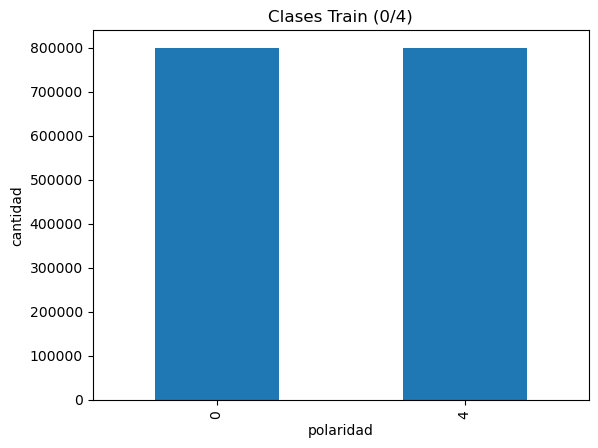

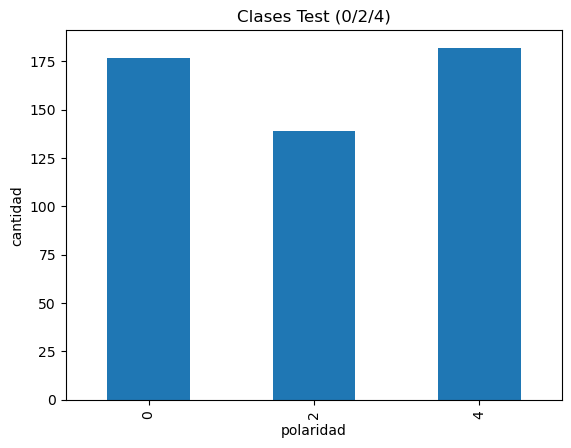

Duplicados eliminados en train: 80224

Train (después duplicados)
            count   prop
polarity               
0         767069  0.505
4         752707  0.495


<Figure size 640x480 with 0 Axes>

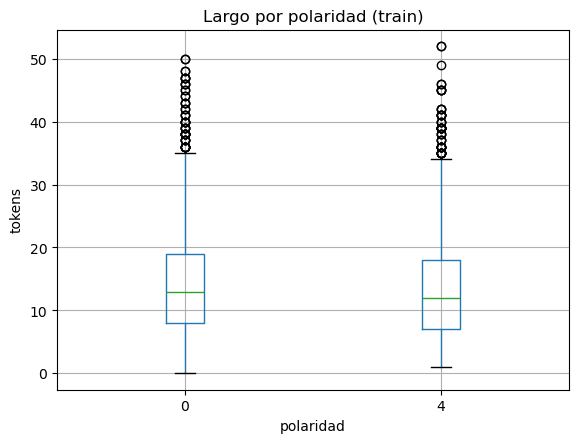

<Figure size 640x480 with 0 Axes>

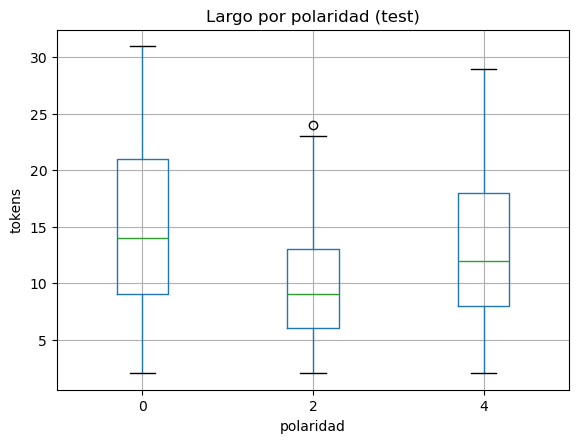

NameError: name 'WordCloud' is not defined

In [6]:
# 3.1 eliminar columnas no informativas
train_df = train_df[["polarity","text","text_clean","text_lemma"]].copy()
test_df  = test_df[["polarity","text","text_clean","text_lemma"]].copy()

# 3.2 distribución clases
def class_stats(df, name):
    counts=df["polarity"].value_counts().sort_index()
    props=(counts/counts.sum()).round(3)
    print(f"\n{name}\n", pd.DataFrame({"count":counts,"prop":props}))

class_stats(train_df, "Train (antes duplicados)")
class_stats(test_df, "Test")

def plot_class_distribution(df,title):
    counts=df["polarity"].value_counts().sort_index()
    plt.figure(); counts.plot(kind="bar")
    plt.title(title); plt.xlabel("polaridad"); plt.ylabel("cantidad"); plt.show()

plot_class_distribution(train_df,"Clases Train (0/4)")
plot_class_distribution(test_df,"Clases Test (0/2/4)")

# 3.3 duplicados
before=len(train_df)
train_df=train_df.drop_duplicates(subset=["text_clean"])
print("Duplicados eliminados en train:", before-len(train_df))
class_stats(train_df, "Train (después duplicados)")

# 3.4 largo por clase (boxplot)
train_df["len"]=train_df["text_clean"].str.split().apply(len)
test_df["len"]=test_df["text_clean"].str.split().apply(len)

plt.figure(); train_df.boxplot(column="len", by="polarity"); plt.title("Largo por polaridad (train)")
plt.suptitle(""); plt.xlabel("polaridad"); plt.ylabel("tokens"); plt.show()

plt.figure(); test_df.boxplot(column="len", by="polarity"); plt.title("Largo por polaridad (test)")
plt.suptitle(""); plt.xlabel("polaridad"); plt.ylabel("tokens"); plt.show()

# 3.5 wordclouds
def wc_for_class(df,label,pref=""):
    text=" ".join(df[df.polarity==label]["text_lemma"])
    wc=WordCloud(width=800,height=400,background_color="white").generate(text)
    plt.figure(figsize=(10,5)); plt.imshow(wc, interpolation="bilinear"); plt.axis("off")
    plt.title(f"{pref}WordCloud clase {label}"); plt.show()

wc_for_class(train_df,0,"Train – "); wc_for_class(train_df,4,"Train – ")
wc_for_class(test_df,0,"Test – "); wc_for_class(test_df,2,"Test – "); wc_for_class(test_df,4,"Test – ")


## 4. Split interno estilo clase

In [ ]:
X = train_df["text_lemma"]
y = train_df["polarity"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("X_train:", X_train.shape, "X_test:", X_test.shape)


# Modelo 1 – Logistic Regression

In [ ]:
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", LogisticRegression(max_iter=300, n_jobs=-1))
])
lr_pipe.fit(X_train, y_train)

train_pred_lr = lr_pipe.predict(X_train)
test_pred_lr  = lr_pipe.predict(X_test)

print("Train")
print(classification_report(y_train, train_pred_lr))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_lr))
print("Confusion matrix interno:\n", confusion_matrix(y_test, test_pred_lr))


## LR en test externo (3 clases por descarte)

In [ ]:
X_ext = test_df["text_lemma"]
y_ext = test_df["polarity"]

proba_pos_lr = lr_pipe.predict_proba(X_ext)[:,1]
low_thr, high_thr = 0.4, 0.6
pred_lr_3 = np.where(proba_pos_lr>high_thr,4,np.where(proba_pos_lr<low_thr,0,2))

print("Test externo (3 clases por descarte)")
print(classification_report(y_ext, pred_lr_3))
print("Confusion matrix externo:\n", confusion_matrix(y_ext, pred_lr_3))

mask_bin_ext = y_ext.isin([0,4])
print("Test externo binario (0/4) referencia")
print(classification_report(y_ext[mask_bin_ext], lr_pipe.predict(X_ext[mask_bin_ext])))


# Modelo 2 – Multinomial Naive Bayes

In [ ]:
nb_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=200000)),
    ("clf", MultinomialNB())
])
nb_pipe.fit(X_train, y_train)

train_pred_nb = nb_pipe.predict(X_train)
test_pred_nb  = nb_pipe.predict(X_test)

print("Train")
print(classification_report(y_train, train_pred_nb))
print("----------------------------------------------------------")
print("Test interno")
print(classification_report(y_test, test_pred_nb))
print("Confusion matrix interno:\n", confusion_matrix(y_test, test_pred_nb))


## NB en test externo (3 clases por descarte)

In [ ]:
proba_pos_nb = nb_pipe.predict_proba(X_ext)[:,1]
pred_nb_3 = np.where(proba_pos_nb>high_thr,4,np.where(proba_pos_nb<low_thr,0,2))

print("Test externo (3 clases por descarte)")
print(classification_report(y_ext, pred_nb_3))
print("Confusion matrix externo:\n", confusion_matrix(y_ext, pred_nb_3))

print("Test externo binario (0/4) referencia")
print(classification_report(y_ext[mask_bin_ext], nb_pipe.predict(X_ext[mask_bin_ext])))


## 5. Resumen comparativo interno

In [ ]:
pd.DataFrame({
    "modelo":["Logistic Regression","Naive Bayes"],
    "acc_test_interno":[(test_pred_lr==y_test).mean(), (test_pred_nb==y_test).mean()]
})


## 6. Baseline TextBlob (3 clases)

In [ ]:
def textblob_predict_3(text):
    pol=TextBlob(text).sentiment.polarity
    if pol>0.1: return 4
    if pol<-0.1: return 0
    return 2

if TEXTBLOB_AVAILABLE:
    pred_tb_3 = test_df["text_clean"].apply(textblob_predict_3).values
    print(classification_report(y_ext, pred_tb_3))
    print("Confusion matrix:\n", confusion_matrix(y_ext, pred_tb_3))
else:
    print("TextBlob no disponible")


## 7. Métrica extra: similitud coseno

In [ ]:
vectorizer = lr_pipe.named_steps["tfidf"]
X_vec = vectorizer.transform(X_ext)

idx_pos = np.where(y_ext.values==4)[0]
idx_neg = np.where(y_ext.values==0)[0]
idx_neu = np.where(y_ext.values==2)[0]

def mean_cosine(idxs_a, idxs_b, n_sample=200):
    rng=np.random.default_rng(0)
    a=rng.choice(idxs_a,size=min(n_sample,len(idxs_a)),replace=False)
    b=rng.choice(idxs_b,size=min(n_sample,len(idxs_b)),replace=False)
    return cosine_similarity(X_vec[a], X_vec[b]).mean()

print("Cos(pos,pos):", mean_cosine(idx_pos, idx_pos))
print("Cos(neg,neg):", mean_cosine(idx_neg, idx_neg))
print("Cos(pos,neg):", mean_cosine(idx_pos, idx_neg))
print("Cos(neu,pos):", mean_cosine(idx_neu, idx_pos))
print("Cos(neu,neg):", mean_cosine(idx_neu, idx_neg))


## 8. Conclusiones (completar)